# **Predicting Waze User Churn**
**Stage 4 - Regression Analysis**

**Situation:** We're more than halfway through our user churn project. Earlier, we completed a project proposal, used Python to explore and analyze Waze's user data, created data visualizations, and conducted a hypothesis test. Now, we want to build a regression model to predict user churn based on a variety of variables. We will build a binomial logistic regression model.

# **Regression modeling**

In this stage we will build a binomial logistic regression model. Logistic regression helps us estimate the probability of an outcome. It allows us to consider more than one variable against the variable we're measuring against. This opens the door for much more thorough and flexible analysis to be completed.
<br/>

**The purpose** of this stage is to conduct exploratory data analysis (EDA) and a binomial logistic regression model.

**The goal** is to build a binomial logistic regression model and evaluate the model's performance.
<br/>

*This stage has three parts:*

**Part 1:** EDA & Checking Model Assumptions

**Part 2:** Model Building and Evaluation

**Part 3:** Interpreting Model Results

# **Build a regression model**

# **PACE stages**


Throughout this notebook, we'll use the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

## **PACE: Plan**

### **Part 1. Imports and data loading**
Importing the data and packages that are needed for building logistic regression models.

In [ ]:
# Packages for numerics + dataframes
import pandas as pd
import numpy as np
# Packages for visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Packages for Logistic Regression & Confusion Matrix
import sklearn.metrics as metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
# Loading the dataset

df = pd.read_csv('waze_dataset.csv')

## **PACE: Analyze**

Some purposes of EDA before constructing a binomial logistic regression model:

+ To identify missing values and outliers that could affect the accuracy of the model.
+ To asses the asumptions of the model and discover relations between variables.

### **Part 2a. Exploring data with EDA**

Analyzing and discovering data, lookinging for correlations, missing data, potential outliers, and/or duplicates.



In [ ]:
print(df.shape)
df.info()

(14999, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


700 mising value in label column.

In [ ]:
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


we'll use `.drop()` to remove the ID column since we don't need this information for our analysis.

In [ ]:
df = df.drop(columns=['ID'])

Now, let's check the class balance of the dependent (target) variable, `label`.

In [ ]:
df['label'].value_counts(normalize=True)

retained    0.822645
churned     0.177355
Name: label, dtype: float64

In [ ]:
df.describe()

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879
std,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036
min,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000
50%,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000
75%,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000
max,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


Many of the columns contain outliers.

### **Part 2b. Creating features**

Let's create features that may be of interest to the stakeholder and/or that are needed to address the business scenario/problem.

#### **`km_per_driving_day`**

We know from earlier EDA that churn rate correlates with distance driven per driving day in the last month. It might be helpful to engineer a feature that captures this information.

1. Creating a new column in `df` called `km_per_driving_day`, which represents the mean distance driven per driving day for each user.

2. Calling the `describe()` method on the new column.

In [ ]:
# 1. Creating `km_per_driving_day` column
df['km_per_driving_day'] = df['driven_km_drives'] / df['driving_days']
# 2. Calling `describe()` on the new column
df['km_per_driving_day'].describe()

count    1.499900e+04
mean              inf
std               NaN
min      3.022063e+00
25%      1.672804e+02
50%      3.231459e+02
75%      7.579257e+02
max               inf
Name: km_per_driving_day, dtype: float64

Some values are infinite. This is the result of there being values of zero in the `driving_days` column. Pandas imputes a value of infinity in the corresponding rows of the new column because division by zero is undefined.

1. Converting these values from infinity to zero. You can use `np.inf` to refer to a value of infinity.

2. Calling `describe()` on the `km_per_driving_day` column to verify that it worked.

In [ ]:
# 1. Converting infinite values to zero
df.loc[df['km_per_driving_day'] == np.inf, 'km_per_driving_day'] = 0
# 2. Confirming that it worked
df['km_per_driving_day'].describe()

count    14999.000000
mean       578.963113
std       1030.094384
min          0.000000
25%        136.238895
50%        272.889272
75%        558.686918
max      15420.234110
Name: km_per_driving_day, dtype: float64

#### **`professional_driver`**

Creating a new, binary feature called `professional_driver` that is a 1 for users who had 60 or more drives <u>**and**</u> drove on 15+ days in the last month.

The objective is to create a new feature that separates professional drivers from other drivers.

To create this column, we'll use the `np.where()` function. This function accepts as arguments:
1. A condition
2. What to return when the condition is true
3. What to return when the condition is false

In [ ]:
# Creating `professional_driver` column
df['professional_driver'] = np.where((df['drives']>=60)&(df['driving_days']>=15), 1,0)

In [ ]:
# 1. Check count of professionals and non-professionals
df['professional_driver'].value_counts()
# 2. Within each class (professional and non-professional) calculating the
#churn rate
df.groupby('professional_driver')['label'].value_counts(normalize=True)

professional_driver  label   
0                    retained    0.801202
                     churned     0.198798
1                    retained    0.924437
                     churned     0.075563
Name: label, dtype: float64

The churn rate for professional drivers is 7.6%, while the churn rate for non-professionals is 19.9%. This seems like it could add predictive signal to the model.

## **PACE: Construct**

After analysis and deriving variables with close relationships, it is time to begin constructing the model.

The independent variables are selected based on previous analysis and intiuition as a first version of the model, they can be reselected after the model has been evaluated.

### **Part 3a. Preparing variables**

Calling `info()` on the dataframe to check the data type of the `label` variable and to verify if there are any missing values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   label                    14299 non-null  object 
 1   sessions                 14999 non-null  int64  
 2   drives                   14999 non-null  int64  
 3   total_sessions           14999 non-null  float64
 4   n_days_after_onboarding  14999 non-null  int64  
 5   total_navigations_fav1   14999 non-null  int64  
 6   total_navigations_fav2   14999 non-null  int64  
 7   driven_km_drives         14999 non-null  float64
 8   duration_minutes_drives  14999 non-null  float64
 9   activity_days            14999 non-null  int64  
 10  driving_days             14999 non-null  int64  
 11  device                   14999 non-null  object 
 12  km_per_driving_day       14999 non-null  float64
 13  professional_driver      14999 non-null  int64  
dtypes: float64(4), int64(8

Because we know from previous EDA that there is no evidence of a non-random cause of the 700 missing values in the `label` column, and because these observations comprise less than 5% of the data, we'll use the `dropna()` method to drop the rows that are missing this data.

In [ ]:
# Dropping rows with missing data in `label` column
df = df.dropna(axis=0)

#### **Imputting outliers**

At times outliers can be changed to the **median, mean, 95th percentile, etc.**

Previously, we determined that seven of the variables had clear signs of containing outliers:

* `sessions`
* `drives`
* `total_sessions`
* `total_navigations_fav1`
* `total_navigations_fav2`
* `driven_km_drives`
* `duration_minutes_drives`

For this analysis, we'll impute the outlying values for these columns, by calculating the **95th percentile** of each column and change to this value any value in the column that exceeds it.

In [ ]:
# Imputing outliers
def imputer(columns):
    for col in columns:
        q95 = df[col].quantile(0.95)
        df.loc[df[col]> q95, col] = q95

imputer(['sessions','drives','total_sessions','total_navigations_fav1','total_navigations_fav2', 'driven_km_drives','duration_minutes_drives'])

In [ ]:
df.describe()

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_driving_day,professional_driver
count,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000
mean,76.539688,63.964683,183.717304,1751.822505,114.562767,27.187216,3944.558631,1792.911210,15.544653,12.182530,581.942399,0.173998
std,67.243178,55.127927,118.720520,1008.663834,124.378550,36.715302,2218.358258,1224.329759,9.016088,7.833835,1038.254509,0.379121
min,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000,0.000000,0.000000
25%,23.000000,20.000000,90.457733,878.500000,10.000000,0.000000,2217.319909,840.181344,8.000000,5.000000,136.168003,0.000000
50%,56.000000,48.000000,158.718571,1749.000000,71.000000,9.000000,3496.545617,1479.394387,16.000000,12.000000,273.301012,0.000000
75%,111.000000,93.000000,253.540450,2627.500000,178.000000,43.000000,5299.972162,2466.928876,23.000000,19.000000,558.018761,0.000000
max,243.000000,200.000000,455.439492,3500.000000,422.000000,124.000000,8898.716275,4668.180092,31.000000,30.000000,15420.234110,1.000000


#### **Encoding categorical variables**

We'll change the data type of the `label` column to be binary. This change is needed to train a logistic regression model.

Assigning a `0` for all `retained` users.

Assigning a `1` for all `churned` users.

Saving this variable as `label2` as to not overwrite the original `label` variable.

In [ ]:
# Creating binary `label2` column
df['label2'] = np.where(df['label']=='churned',1,0)

### **Part 3b. Determining whether assumptions have been met**

The following are the assumptions for logistic regression:

* Independent observations (This refers to how the data was collected.)

* No extreme outliers

* Little to no multicollinearity among X predictors

* Linear relationship between X and the **logit** of y

For the first assumption, we can assume that observations are independent.

The second assumption has already been addressed.

The last assumption will be verified after modeling.

Modeling assumptions are often violated, and depending on the specifics of our use case and the severity of the violation, it might not affect the model much at all or it will result in a failed model.

#### **Collinearity**

Checking the correlation among predictor variables.

In [ ]:
# Generating a correlation matrix
cor = df.corr()
cor[cor>=0.7]

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_driving_day,professional_driver,label2
sessions,1.000000,0.996942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drives,0.996942,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_sessions,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_days_after_onboarding,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_navigations_fav1,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_navigations_fav2,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
driven_km_drives,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
duration_minutes_drives,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
activity_days,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.947687,NaN,NaN,NaN
driving_days,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.947687,1.000000,NaN,NaN,NaN


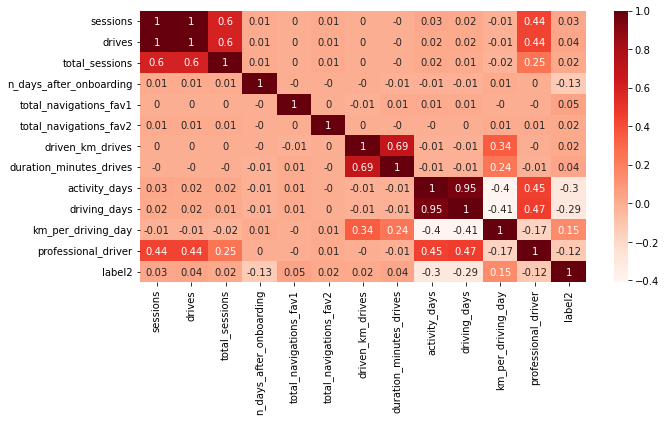

In [ ]:
# Plotting
 correlation heatmap
plt.figure(figsize=(10,5))
sns.heatmap(data=df.corr(method='pearson').round(2), cmap='Reds',annot =True)

If there are predictor variables that have a Pearson correlation coefficient value greater than the **absolute value of 0.7**, these variables are strongly multicollinear. Therefore, only one of these variables should be used in our model.

0.7 is an arbitrary threshold. Some industries may use 0.6, 0.8, etc.

Variables are multicollinear with each other:

> `drives` and `sessions`, `driving_days` and `activity_days`.

### **Part 3c. Creating dummies**

Since we have selected `device` as an X variable, we will need to create dummy variables since this variable is categorical.

In cases with many categorical variables, we can use pandas built-in `pd.get_dummies()`, or you can use scikit-learn's `OneHotEncoder()` function.

Variables with many categories should only be dummied if absolutely necessary. Each category will result in a coefficient for our model which can lead to overfitting.

Because this dataset only has one remaining categorical feature (`device`), it's not necessary to use one of these special functions. We can just implement the transformation directly.

Creating a new, binary column called `device2` that encodes user devices as follows:

* `Android` -> `0`
* `iPhone` -> `1`

In [ ]:
df['device2'] = np.where(df['device']=='iPhone',1,0)

### **Part 3d. Model building**

#### **Assigning predictor variables and target**

To build our model we need to determine what X variables we want to include in our model to predict our target&mdash;`label2`.

Dropping the following variables and assigning the results to `X`:

* `label` (this is the target)
* `label2` (this is the target)
* `device` (this is the non-binary-encoded categorical variable)
* `sessions` (this had high multicollinearity)
* `driving_days` (this had high multicollinearity)

`sessions` and `driving_days` were selected to be dropped, rather than `drives` and `activity_days`. The reason for this is that the features that were kept for modeling had slightly stronger correlations with the target variable than the features that were dropped.

In [ ]:
# Isolating predictor variables
x = df.drop(columns=['label','label2','device','sessions','driving_days'])

Now, isolate the dependent (target) variable. Assign it to a variable called `y`.

In [ ]:
# Isolating target variable
y = df['label2']
x.head()

,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,km_per_driving_day,professional_driver,device2
0,200,296.748273,2276,208,0,2628.845068,1985.775061,28,138.360267,1,0
1,107,326.896596,1225,19,64,8898.716275,3160.472914,13,1246.901868,0,1
2,95,135.522926,2651,0,0,3059.148818,1610.735904,14,382.393602,0,0
3,40,67.589221,15,322,7,913.591123,587.196542,7,304.530374,0,1
4,68,168.247020,1562,166,5,3950.202008,1219.555924,27,219.455667,1,0


#### **Splitting the data**

Let's use scikit-learn's `train_test_split()` function to perform a train/test split on our data using the X and y variables we assigned above.

It is important to do a train test to obtain accurate predictions. We always want to fit our model on our training set and evaluate our model on our test set to avoid data leakage.

Because the target class is imbalanced (82% retained vs. 18% churned), we want to make sure that we don't get an unlucky split that over- or under-represents the frequency of the minority class. Setting the function's `stratify` parameter to `y` cam ensure that the minority class appears in both train and test sets in the same proportion that it does in the overall dataset.

In [ ]:
# Performing the train-test split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25, stratify=y,random_state=42)

In [ ]:
# head
y_train.head()

dtype('int64')

Let's use scikit-learn to instantiate a logistic regression model. Adding the argument `penalty = None`.

It is important to add `penalty = None` since our predictors are unscaled.

Then, fitting the model on `X_train` and `y_train`.

In [ ]:
clf = LogisticRegression(penalty='none',solver='saga')
model = clf.fit(x_train, y_train)

Let's call the `.coef_` attribute on the model to get the coefficients of each variable.  The coefficients are in order of how the variables are listed in the dataset. The coefficients represent the change in the **log odds** of the target variable for **every one unit increase in X**.

We can create a series whose index is the column names and whose values are the coefficients in `model.coef_`.

In [ ]:
pd.Series(index=np.array(x_train.columns), data= model.coef_.ravel())


drives                     0.000629
total_sessions            -0.001012
n_days_after_onboarding   -0.000556
total_navigations_fav1     0.000135
total_navigations_fav2    -0.001209
driven_km_drives          -0.000149
duration_minutes_drives    0.000056
activity_days             -0.006989
km_per_driving_day         0.000312
professional_driver       -0.000099
device2                   -0.000071
dtype: float64

Calling the model's `intercept_` attribute to get the intercept of the model.

In [ ]:
model.intercept_

array([-0.00011547])

#### **Checking final assumption**

Let's verify the linear relationship between X and the estimated log odds (known as logits) by making a regplot.

We'll call the model's `predict_proba()` method to generate the probability of response for each sample in the training data. (The training data is the argument to the method.) We'll assign the result to a variable called `training_probabilities`. This results in a 2-D array where each row represents a user in `X_train`. The first column is the probability of the user not churning, and the second column is the probability of the user churning.

In [ ]:
training_probabilities = model.predict_proba(x_train)
training_probabilities[::,-1]
x_train.head()

,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,km_per_driving_day,professional_driver,device2
152,108,186.192746,3116,243,124,8898.716275,4668.180092,24,612.305861,1,1
11899,2,3.487590,794,114,18,3286.545691,1780.902733,5,3286.545691,0,1
10937,139,347.106403,331,4,7,7400.838975,2349.305267,15,616.736581,0,0
669,108,455.439492,2320,11,4,6566.424830,4558.459870,18,410.401552,1,1
8406,10,89.475821,2478,135,0,1271.248661,938.711572,27,74.779333,0,1


In logistic regression, the relationship between a predictor variable and the dependent variable does not need to be linear, however, the log-odds (a.k.a., logit) of the dependent variable with respect to the predictor variable should be linear. Here is the formula for calculating log-odds, where _p_ is the probability of response:
<br>
$$
logit(p) = ln(\frac{p}{1-p})
$$
<br>

1. Creating a dataframe called `logit_data` that is a copy of `df`.

2. Creating a new column called `logit` in the `logit_data` dataframe. The data in this column should represent the logit for each user.


In [ ]:
# 1.
logit_data = x_train.copy()
# 2.
logit_data['logit'] = np.log(training_probabilities[::,-1]/(1 - training_probabilities[::,-1]))
logit_data.shape

(10724, 12)

Let's plot a regplot where the x-axis represents an independent variable and the y-axis represents the log-odds of the predicted probabilities.

In an exhaustive analysis, this would be plotted for each continuous or discrete predictor variable. Here we show only `driving_days`.

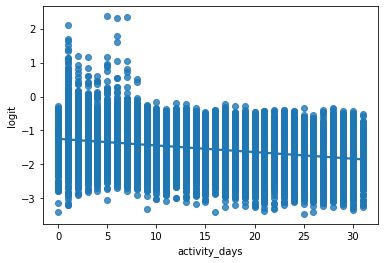

In [ ]:
# Plotting regplot of `activity_days` log-odds
sns.regplot(data=logit_data, x='activity_days', y='logit')

## **PACE: Execute**

### **Part 4a. Results and evaluation**

If the logistic assumptions are met, the model results can be appropriately interpreted.

In [ ]:
# Generating predictions on X_test
y_pred = model.predict(x_test)

Now, we'll use the `score()` method on the model with `X_test` and `y_test` as its two arguments. The default score in scikit-learn is **accuracy**.

In [ ]:
# Scoring the model (accuracy) on the test data
model.score(x_test, y_test)

0.8226573426573427

### **Part 4b. Showing results with a confusion matrix**

array([0, 1])

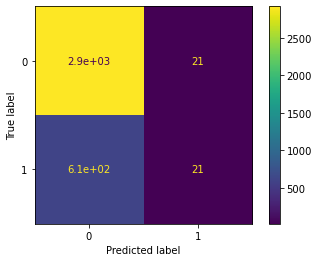

In [ ]:
cm = metrics.confusion_matrix(y_test.values, y_pred ,labels= model.classes_)
myplot = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = model.classes_)
myplot.plot()
model.classes_

In [ ]:
# precision
metrics.precision_score(y_test,y_pred)

0.5

In [ ]:
# recall
metrics.recall_score(y_test,y_pred)

0.033123028391167195

In [ ]:
# Creating a classification report
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.99      0.90      2941
           1       0.50      0.03      0.06       634

    accuracy                           0.82      3575
   macro avg       0.66      0.51      0.48      3575
weighted avg       0.77      0.82      0.75      3575



The model has decent precision but very low recall, which means that it makes a lot of false negative predictions and fails to capture users who will churn.

Let's generate a bar graph of the model's coefficients for a visual representation of the importance of the model's features.

In [ ]:
# Creating a list of (column_name, coefficient) tuples
results = pd.DataFrame(index=x_train.columns, data=abs(np.exp(model.coef_[0])),columns=['Beta'])
# Sortting tingthe list by coefficient value
results2 = abs(results['Beta']).sort_values(ascending=False)
results2.index

Index(['activity_days', 'total_navigations_fav2', 'total_sessions', 'drives',
       'n_days_after_onboarding', 'km_per_driving_day', 'driven_km_drives',
       'total_navigations_fav1', 'professional_driver', 'device2',
       'duration_minutes_drives'],
      dtype='object')

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 <a list of 11 Text major ticklabel objects>)

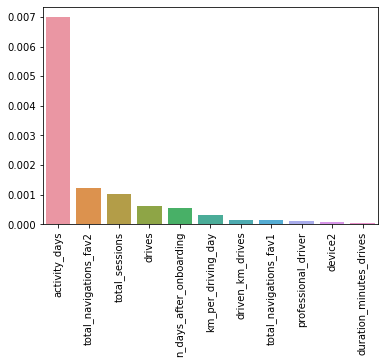

In [ ]:
# Plot the feature importances
sns.barplot(data=results.T, order = ['activity_days', 'total_navigations_fav2', 'total_sessions', 'drives',
       'n_days_after_onboarding', 'km_per_driving_day', 'driven_km_drives','total_navigations_fav1', 'professional_driver', 'device2','duration_minutes_drives'])
plt.xticks(rotation=90)

### **Part 4c. Conclusion**

Now that we've built our regression model, the next step is to share our findings with the Waze leadership team.

+ It seems that activity days had the most infulence on churn state, where users with higher activity days tend to churn less which is not surprising.
+ `drives` was less correlated that what I thought it would be.
+ I thought that drives would be effective bucause I assumed that users with more drives we tend to depend on the app more and therfore won't churn. But they could also use the app many times to reach the same distination (e.g. workplace) and then churn.
+ I would recommend using the model to discover the relation between variable and discover data trends and not using it for prediction since it has very low recall.
+ To improve the model we can try to focus on important parameters only rather than including all these variables. Or joining a dataset that contains equal percentages of churn vs retainedstatus.
+ Additional features we would like to have to improve the model: App rate by the user, app session duration and location of user can be of great benefit.